# Dynamic and Adaptive Attention in — Practical Implementation 3

| Sr. No. | Real-model experiment | Models |
|---|---|---|
| 1 | Is attention really query-/content-dependent? (the *"it was too tired / wide"* example) | BERT-base |
| 2 | KV-cache: measured vs. formula, cache size of MHA vs. GQA models, with/without cache speed | GPT-2, Qwen2.5-0.5B (+ configs of larger LLMs) |
| 3 | Quantization: size, speed and perplexity from FP16 down to 2-bit | OPT-125m |
| 4 | Hooking real attention; FlashAttention-style tiling on real Q/K/V; SDPA memory/time | GPT-2 |
| 5 | **Dynamic sparsity on a real LM**: local / sink+local / top-k masks, **per-head span calibration** | GPT-2 |
| 6 | **Token merging (ToMe)** and token dropping inside a real ViT | ViT-B/16 |
| 7 | Attention rollout on ViT; rollout vs. **attention flow** on GPT-2 | ViT-B/16, GPT-2 |


In [1]:
# =============================================================================
# Required Python Packages
# =============================================================================
#
# Install the dependencies below before running the transformer experiments.
#
# Packages:
#   - transformers : Hugging Face transformer models and tokenizers
#   - datasets     : Loading datasets such as WikiText-2 and Tiny ImageNet
#   - networkx     : Graph construction and maximum-flow analysis
#   - accelerate   : Efficient model/device handling for Hugging Face models
#
# Installation command:
#   pip install transformers datasets networkx accelerate
#
# For Jupyter/Colab notebooks, the command can be executed as:
#   !pip -q install transformers datasets networkx accelerate
#
# =============================================================================

!pip -q install transformers datasets networkx accelerate

In [2]:
# =============================================================================
# Experimental Setup for Language-Model Attention and Perplexity Analysis
# =============================================================================
#
# Description:
# This script initializes the computational environment used for experiments
# involving transformer language models, attention mechanisms, and sparse
# attention.
#
# It provides common utilities for:
#   - Loading pretrained causal language models and tokenizers.
#   - Selecting CPU or CUDA automatically.
#   - Configuring the numerical precision used by the model.
#   - Loading WikiText-2 evaluation text.
#   - Splitting text into fixed-length token windows.
#   - Measuring language-model perplexity.
#   - Synchronizing and releasing GPU memory.
#
# Device and precision:
#   - CUDA is used when available.
#   - Float16 is used on CUDA for more efficient inference.
#   - Float32 is used on CPU.
#
# Reproducibility:
# NumPy and PyTorch random seeds are fixed to 0 so that experiments involving
# random sampling or initialization can be reproduced.
#
# Dataset:
# The primary evaluation text is WikiText-2 (raw version). If the dataset
# cannot be downloaded, a repetitive fallback text is used instead. Results
# obtained with the fallback text should not be interpreted as meaningful
# language-model perplexity measurements.
#
# Main utilities:
#   - sync():
#       Synchronizes CUDA before timing GPU operations.
#
#   - free():
#       Performs Python garbage collection and clears the CUDA cache.
#
#   - load_text():
#       Loads and prepares the evaluation text.
#
#   - get_windows():
#       Tokenizes the text and divides it into fixed-length sequences.
#
#   - load_lm():
#       Loads a pretrained causal language model and tokenizer.
#
#   - ppl_of():
#       Computes perplexity over a collection of token windows.
#
# The functions defined here are intended to be reused by later experiments
# involving full attention, sparse attention, attention spans, and other
# transformer modifications.
#
# =============================================================================

import os, io, gc, math, time, copy, warnings
import numpy as np
import torch, torch.nn.functional as F
import matplotlib.pyplot as plt
import transformers
from transformers import AutoTokenizer, AutoModel, AutoModelForCausalLM, AutoConfig

warnings.filterwarnings("ignore")
device = "cuda" if torch.cuda.is_available() else "cpu"
DTYPE = torch.float16 if device == "cuda" else torch.float32
torch.manual_seed(0); np.random.seed(0)
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False})
print("transformers", transformers.__version__, "| torch", torch.__version__, "| device:", device,
      (torch.cuda.get_device_name(0) if device == "cuda" else ""))

def sync():
    if device == "cuda": torch.cuda.synchronize()

def free():
    gc.collect()
    if device == "cuda": torch.cuda.empty_cache()

FALLBACK = ("The history of attention in neural networks began with machine translation, where a decoder learned to look "
            "back at the encoder states instead of relying on one fixed summary vector. ") * 200

def load_text(n_chars=80000):
    try:
        from datasets import load_dataset
        ds = load_dataset("Salesforce/wikitext", "wikitext-2-raw-v1", split="test")
        return "\n".join(t for t in ds["text"] if t.strip())[:n_chars]
    except Exception as e:
        print("!! could not load WikiText-2 (", e, ") -> using a repetitive fallback text; perplexities will NOT be meaningful")
        return FALLBACK

TEXT = load_text()

def get_windows(tok, T, n):
    ids = tok(TEXT, return_tensors="pt").input_ids[0]
    assert len(ids) >= T * n, f"text too short: {len(ids)} tokens"
    return [ids[i * T:(i + 1) * T] for i in range(n)]

def load_lm(name, dtype=None, **kw):
    tok = AutoTokenizer.from_pretrained(name)
    m = AutoModelForCausalLM.from_pretrained(name, torch_dtype=dtype or DTYPE, **kw).to(device).eval()
    return tok, m

def ppl_of(model, windows, dev=None):
    dev = dev or device; nll = 0.0; cnt = 0
    for w in windows:
        ids = w[None].to(dev)
        with torch.no_grad():
            logits = model(ids).logits.float()
        nll += F.cross_entropy(logits[0, :-1], ids[0, 1:], reduction="sum").item(); cnt += ids.shape[1] - 1
    return math.exp(nll / cnt)
print("setup done; text tokens available ~", len(TEXT) // 4)

transformers 5.16.1 | torch 2.11.0+cu128 | device: cuda Tesla T4


README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

wikitext-2-raw-v1/test-00000-of-00001.pa(…): reconstructing file:   0%|          |  0.00B /  733kB            

wikitext-2-raw-v1/test-00000-of-00001.pa(…): downloading bytes:           |  0.00B            

wikitext-2-raw-v1/train-00000-of-00001.p(…): reconstructing file:   0%|          |  0.00B / 6.36MB            

...

wikitext-2-raw-v1/validation-00000-of-00(…): downloading bytes:           |  0.00B            

Generating test split:   0%|          | 0/4358 [00:00<?, ? examples/s]

Generating train split:   0%|          | 0/36718 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/3760 [00:00<?, ? examples/s]

setup done; text tokens available ~ 20000


## 1) Is attention really query-dependent?

Example: *"The animal didn't cross the street because **it** was too tired / wide."*

A **bidirectional** model (BERT) is needed here: in a causal model like GPT-2, the query of *it* cannot see the adjective that follows. We measure, for every layer and head of `bert-base-uncased`, how much *it* attends to **animal** vs. **street**, and how that changes when only the last word changes.

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  440MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


['[CLS]', 'the', 'animal', 'didn', "'", 't', 'cross', 'the', 'street', 'because', 'it', 'was', 'too', 'tired', '.', '[SEP]']


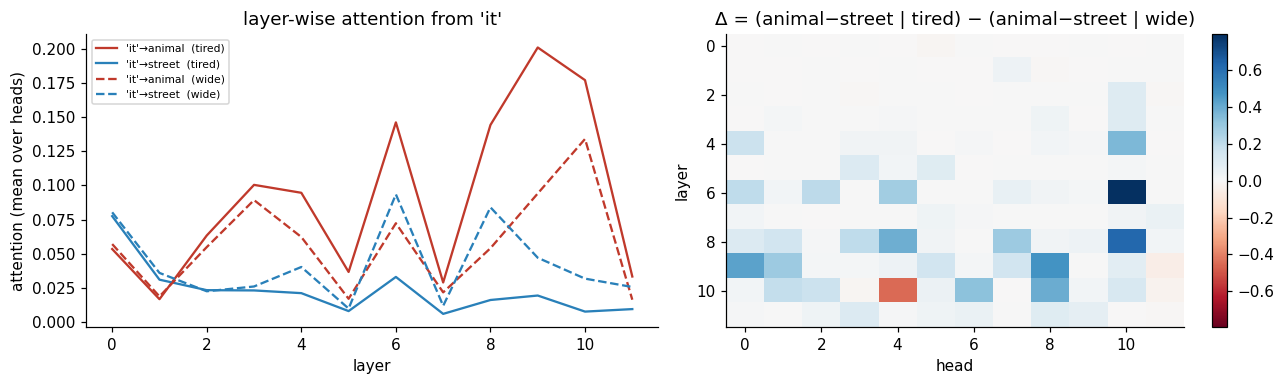

layer head | animal/street (tired) | animal/street (wide)
    6   10 | 0.284 / 0.067     | 0.012 / 0.590
    8   10 | 0.676 / 0.000     | 0.309 / 0.259
    9    8 | 0.454 / 0.003     | 0.023 / 0.045
   10    4 | 0.166 / 0.009     | 0.619 / 0.009
    9    0 | 0.608 / 0.002     | 0.255 / 0.074


In [3]:
# =============================================================================
# BERT Attention Analysis for Context-Dependent Pronoun Resolution
# =============================================================================
#
# Description:
# This experiment examines how BERT's attention patterns change when the same
# pronoun appears in two different sentence contexts.
#
# The two sentences differ only in the final adjective:
#   - "The animal didn't cross the street because it was too tired."
#   - "The animal didn't cross the street because it was too wide."
#
# The attention paid by the token "it" to the tokens "animal" and "street" is
# extracted from every BERT layer and attention head.
#
# The analysis computes:
#   - Attention from "it" to "animal".
#   - Attention from "it" to "street".
#   - The difference between these attention values across the two contexts.
#
# The resulting visualizations show:
#   1. Layer-wise mean attention from "it" to "animal" and "street".
#   2. A layer/head heatmap of the context-dependent attention difference.
#
# A positive value in the delta matrix indicates that the relative attention
# from "it" toward "animal" compared with "street" is higher in the "tired"
# context than in the "wide" context.
#
# The final table identifies the five layer/head combinations with the largest
# absolute context-dependent attention differences.
#
# Model:
#   bert-base-uncased
#
# Requirements:
#   - PyTorch
#   - Transformers
#   - NumPy
#   - Matplotlib
#
# =============================================================================

tok_b = AutoTokenizer.from_pretrained("bert-base-uncased")
bert = AutoModel.from_pretrained("bert-base-uncased", attn_implementation="eager").to(device).eval()

sents = {"tired": "The animal didn't cross the street because it was too tired.",
         "wide":  "The animal didn't cross the street because it was too wide."}

def bert_attn(sentence):
    enc = tok_b(sentence, return_tensors="pt").to(device)
    toks = tok_b.convert_ids_to_tokens(enc["input_ids"][0])
    with torch.no_grad():
        out = bert(**enc, output_attentions=True)
    return toks, torch.stack(out.attentions)[:, 0].float().cpu()          # (L, H, T, T)

res = {k: bert_attn(v) for k, v in sents.items()}
toks = res["tired"][0]
i_it, i_an, i_st = toks.index("it"), toks.index("animal"), toks.index("street")
print(toks)

to_an = {k: A[:, :, i_it, i_an] for k, (t, A) in res.items()}    # (L, H)
to_st = {k: A[:, :, i_it, i_st] for k, (t, A) in res.items()}
delta = (to_an["tired"] - to_st["tired"]) - (to_an["wide"] - to_st["wide"])   # >0: 'it' shifts toward animal for "tired"

fig, axes = plt.subplots(1, 2, figsize=(12, 3.6))
L = delta.shape[0]
for k, ls in [("tired", "-"), ("wide", "--")]:
    axes[0].plot(range(L), to_an[k].mean(1), ls, color="#c0392b", label=f"'it'→animal  ({k})")
    axes[0].plot(range(L), to_st[k].mean(1), ls, color="#2980b9", label=f"'it'→street  ({k})")
axes[0].set_xlabel("layer"); axes[0].set_ylabel("attention (mean over heads)"); axes[0].legend(fontsize=7); axes[0].set_title("layer-wise attention from 'it'")
im = axes[1].imshow(delta.numpy(), cmap="RdBu", vmin=-abs(delta).max(), vmax=abs(delta).max(), aspect="auto")
axes[1].set_xlabel("head"); axes[1].set_ylabel("layer"); axes[1].set_title("Δ = (animal−street | tired) − (animal−street | wide)")
plt.colorbar(im, ax=axes[1]); plt.tight_layout(); plt.show()

top = torch.topk(delta.abs().flatten(), 5).indices
print(f"{'layer':>5} {'head':>4} | animal/street (tired) | animal/street (wide)")
for f_ in top:
    l, h = divmod(int(f_), delta.shape[1])
    print(f"{l:>5} {h:>4} | {to_an['tired'][l,h]:.3f} / {to_st['tired'][l,h]:.3f}     | {to_an['wide'][l,h]:.3f} / {to_st['wide'][l,h]:.3f}")

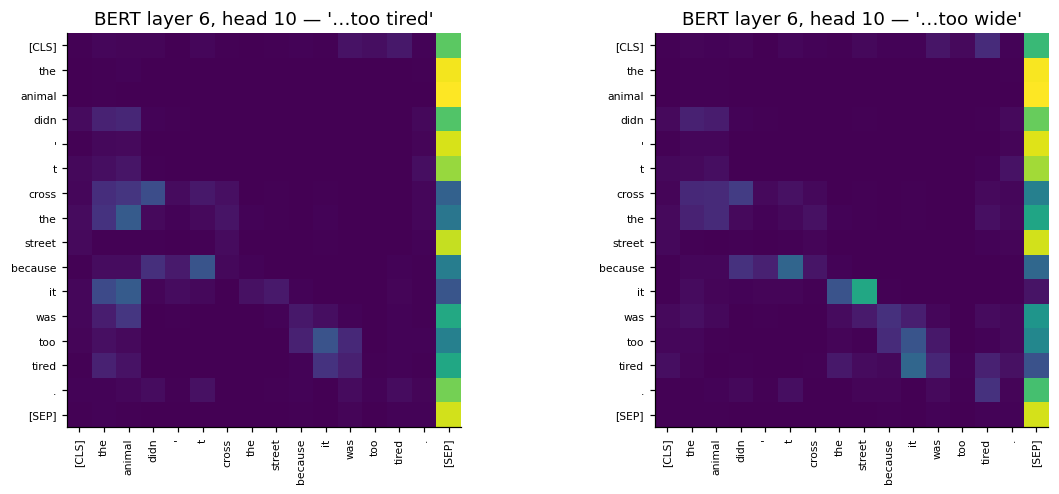

In [4]:
# =============================================================================
# BERT Attention-Head Visualization for Context Comparison
# =============================================================================
#
# Description:
# This visualization examines the attention pattern of the single BERT
# layer/head combination with the largest context-dependent difference between
# the "tired" and "wide" sentences.
#
# The layer and head are selected by finding the maximum absolute value in the
# previously computed `delta` matrix.
#
# Two attention heatmaps are then displayed side by side:
#   - The attention pattern for the sentence ending in "too tired".
#   - The attention pattern for the sentence ending in "too wide".
#
# Each heatmap shows the attention matrix for the selected BERT layer and
# attention head, with tokens displayed on both axes.
#
# The visualization allows the attention pattern to be compared directly
# between the two contexts while keeping the same layer, head, and token
# positions.
#
# After visualization, the BERT model is deleted and available memory is
# released.
#
# Required variables:
#   - delta : previously computed context-dependent attention differences.
#   - res   : previously computed attention matrices for both sentences.
#   - toks  : tokenized sentence.
#   - bert  : loaded BERT model.
#   - free(): memory cleanup utility.
#
# =============================================================================

l, h = divmod(int(torch.topk(delta.abs().flatten(), 1).indices[0]), delta.shape[1])
fig, axes = plt.subplots(1, 2, figsize=(11, 4.6))
for ax, k in zip(axes, ["tired", "wide"]):
    ax.imshow(res[k][1][l, h].numpy(), cmap="viridis"); ax.set_xticks(range(len(toks))); ax.set_xticklabels(toks, rotation=90, fontsize=7)
    ax.set_yticks(range(len(toks))); ax.set_yticklabels(toks, fontsize=7); ax.set_title(f"BERT layer {l}, head {h} — '…too {k}'")
plt.tight_layout(); plt.show()
del bert; free()

**Look for:** heads where the *it → animal / street* balance flips with the adjective (red/blue cells above). Most heads will show little change: attention is dynamic, but individual heads are specialised.

## 2) The KV cache on real models

### 2.1 Measured cache, and what the cache buys you

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (18219 > 1024). Running this sequence through the model will result in indexing errors


GPT-2 (MHA, 12 heads x 12 layers), 512 tokens, 16-bit:
  measured cache : 18.87 MB
  Theoretical memory size of GPT-2's KV cache : 18.87 MB

new tokens |  with KV cache (s) |  without (s) | speed-up
        64 |               0.63 |         0.59 | 0.9x
       128 |               1.23 |         1.65 | 1.3x
       256 |               2.92 |         2.37 | 0.8x
       384 |               3.77 |         4.34 | 1.2x


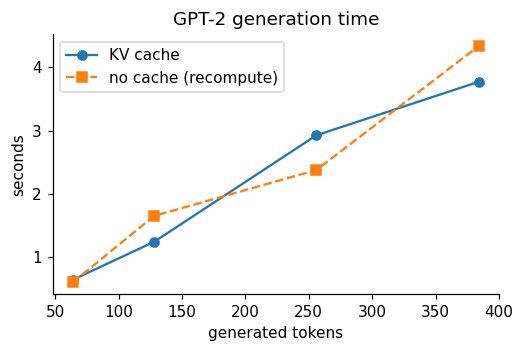

In [26]:
# =============================================================================
# GPT-2 KV-Cache Memory and Generation-Speed Benchmark
# =============================================================================
#
# Description:
# This experiment measures the memory footprint of the key-value (KV) cache
# used during autoregressive GPT-2 generation and compares generation speed
# with and without KV caching.
#
# The experiment has two main parts:
#
#   1. KV-cache memory validation:
#      - Runs GPT-2 on a 512-token sequence with caching enabled.
#      - Measures the actual memory occupied by the returned past key/value
#        tensors.
#      - Computes the expected cache size using the analytical memory formula.
#      - Compares the measured and theoretical values.
#
#   2. Generation-speed benchmark:
#      - Generates several different numbers of new tokens.
#      - Measures generation time with KV caching enabled.
#      - Measures generation time without caching, requiring previous tokens to
#        be recomputed.
#      - Reports the resulting speed-up from KV caching.
#
# KV-cache representation:
# Hugging Face Transformers versions may return the cache in different formats.
# `cache_tensors()` handles several common representations, including legacy
# tuple-based caches and newer cache objects.
#
# Memory calculation:
# `cache_bytes()` measures the actual number of bytes occupied by all key and
# value tensors in the cache.
#
# `formula_bytes()` computes the expected cache size from the model
# configuration:
#   - Number of layers.
#   - Number of key/value heads.
#   - Head dimension.
#   - Sequence length.
#   - Bytes per element.
#
# The generation benchmark uses deterministic greedy decoding and measures the
# wall-clock time required to generate 64, 128, 256, and 384 new tokens.
#
# CUDA synchronization is performed before and after timing so that asynchronous
# GPU execution does not distort the measured generation times.
#
# The final plot compares generation time with and without KV caching as the
# number of generated tokens increases.
#
# Required variables/functions:
#   - load_lm()
#   - TEXT
#   - sync()
#   - free()
#   - time
#   - torch
#   - matplotlib.pyplot as plt
#
# Model:
#   gpt2
#
# =============================================================================

def cache_tensors(pkv):
    if hasattr(pkv, "to_legacy_cache"):
        try: pkv = pkv.to_legacy_cache()
        except Exception: pass
    if isinstance(pkv, (tuple, list)): return [(l[0], l[1]) for l in pkv]
    if hasattr(pkv, "layers"):         return [(l.keys, l.values) for l in pkv.layers]
    if hasattr(pkv, "key_cache"):      return list(zip(pkv.key_cache, pkv.value_cache))
    raise RuntimeError("unknown cache type: " + str(type(pkv)))

def cache_bytes(pkv):
    return sum(k.numel() * k.element_size() + v.numel() * v.element_size() for k, v in cache_tensors(pkv))

def formula_bytes(cfg, n, bytes_per):
    H = cfg.num_attention_heads; nkv = getattr(cfg, "num_key_value_heads", None) or H
    dh = getattr(cfg, "head_dim", None) or cfg.hidden_size // H
    return 2 * n * dh * nkv * cfg.num_hidden_layers * bytes_per

tok_g, gpt = load_lm("gpt2")
ids = tok_g(TEXT, return_tensors="pt").input_ids[:, :512].to(device)
with torch.no_grad():
    out = gpt(ids, use_cache=True)
bp = next(gpt.parameters()).element_size()
print(f"GPT-2 (MHA, 12 heads x 12 layers), 512 tokens, {bp*8}-bit:")
print(f"  measured cache : {cache_bytes(out.past_key_values)/1e6:.2f} MB")
print(f"  Theoretical memory size of GPT-2's KV cache : {formula_bytes(gpt.config, 512, bp)/1e6:.2f} MB")

def gen_time(model, tok, new, use_cache):
    x = tok("The history of attention mechanisms", return_tensors="pt").input_ids.to(device)
    sync(); t = time.time()
    with torch.no_grad():
        model.generate(x, max_new_tokens=new, min_new_tokens=new, do_sample=False, use_cache=use_cache, pad_token_id=tok.eos_token_id)
    sync(); return time.time() - t

gen_time(gpt, tok_g, 8, True)   # warm-up
rows = [(n_, gen_time(gpt, tok_g, n_, True), gen_time(gpt, tok_g, n_, False)) for n_ in (64, 128, 256, 384)]
print(f"\n{'new tokens':>10} | {'with KV cache (s)':>18} | {'without (s)':>12} | speed-up")
for n_, a_, b_ in rows: print(f"{n_:>10} | {a_:>18.2f} | {b_:>12.2f} | {b_/a_:.1f}x")
plt.figure(figsize=(5, 3.3)); plt.plot([r[0] for r in rows], [r[1] for r in rows], "o-", label="KV cache"); plt.plot([r[0] for r in rows], [r[2] for r in rows], "s--", label="no cache (recompute)")
plt.xlabel("generated tokens"); plt.ylabel("seconds"); plt.legend(); plt.title("GPT-2 generation time"); plt.tight_layout(); plt.show()
del gpt, out; free()

### 2.2 GQA in a real model: Qwen2.5-0.5B (14 query heads, 2 KV heads)

In [28]:
# =============================================================================
# Qwen2.5-0.5B GQA KV-Cache Memory Comparison
# =============================================================================
#
# Description:
# This experiment measures the KV-cache memory footprint of Qwen2.5-0.5B and
# compares its grouped-query attention (GQA) layout with an equivalent model
# using standard multi-head attention (MHA).
#
# Qwen uses:
#   - A larger number of query heads.
#   - A smaller number of key/value (KV) heads.
#
# Because the KV cache stores keys and values rather than a separate copy for
# every query head, using fewer KV heads can substantially reduce the memory
# required during autoregressive generation.
#
# The experiment:
#   1. Loads Qwen2.5-0.5B.
#   2. Runs a 512-token sequence with KV caching enabled.
#   3. Measures the actual memory occupied by the returned cache.
#   4. Computes the theoretical cache size using the model's GQA configuration.
#   5. Computes the hypothetical cache size if the same model used standard MHA,
#      where the number of KV heads equals the number of query heads.
#   6. Reports the resulting memory reduction factor.
#
# The measured cache size and analytical formula provide a consistency check
# for the cache representation returned by the installed Transformers version.
#
# If the model cannot be downloaded or loaded, the experiment is skipped and
# the exception is printed without stopping the rest of the notebook.
#
# Required variables/functions:
#   - load_lm()
#   - TEXT
#   - cache_bytes()
#   - formula_bytes()
#   - device
#   - free()
#
# Model:
#   Qwen/Qwen2.5-0.5B
#
# =============================================================================

try:
    tok_q, qwen = load_lm("Qwen/Qwen2.5-0.5B")
    idq = tok_q(TEXT, return_tensors="pt").input_ids[:, :512].to(device)
    with torch.no_grad():
        outq = qwen(idq, use_cache=True)
    c = qwen.config; bp = next(qwen.parameters()).element_size()
    meas = cache_bytes(outq.past_key_values)
    mha_equiv = formula_bytes(type("C", (), dict(num_attention_heads=c.num_attention_heads, num_key_value_heads=c.num_attention_heads,
                                                 hidden_size=c.hidden_size, num_hidden_layers=c.num_hidden_layers))(), 512, bp)
    print(f"Qwen2.5-0.5B: {c.num_attention_heads} query heads, {c.num_key_value_heads} KV heads, {c.num_hidden_layers} layers")
    print(f"  measured cache (512 tokens)         : {meas/1e6:.2f} MB")
    print(f"  Theoretical memory size of KV cache with its GQA layout         : {formula_bytes(c, 512, bp)/1e6:.2f} MB")
    print(f"  same model if it were plain MHA     : {mha_equiv/1e6:.2f} MB   -> GQA saves {mha_equiv/meas:.1f}x")
    del qwen, outq
except Exception as e:
    print("Qwen demo skipped:", repr(e))
free()

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

Qwen2.5-0.5B: 14 query heads, 2 KV heads, 24 layers
  measured cache (512 tokens)         : 6.29 MB
  Theoretical memory size of KV cache with its GQA layout         : 6.29 MB
  same model if it were plain MHA     : 44.04 MB   -> GQA saves 7.0x


config.json:   0%|          | 0.00/689 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/653 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/571 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/686 [00:00<?, ?B/s]

model                  q-heads kv-heads  KB/token  GB @32k ctx
gpt2-xl                     25       25     307.2        10.07
opt-1.3b                    32       32     196.6         6.44
Mistral-7B-v0.1             32        8     131.1         4.29
Qwen2.5-7B                  28        4      57.3         1.88
Qwen2.5-0.5B                14        2      12.3         0.40


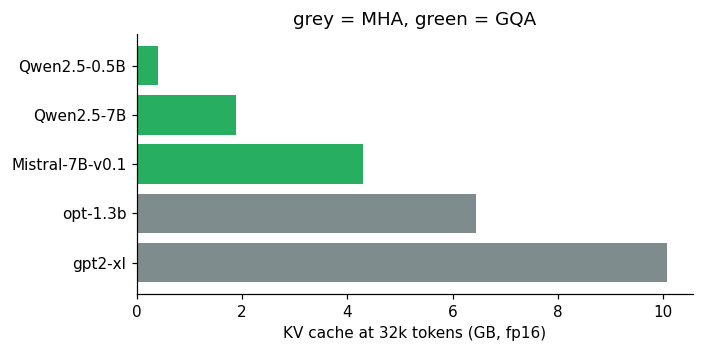

In [29]:
# KV-cache footprint of well-known architectures, straight from their Hugging Face configs (no weights downloaded)
# Compare KV-cache memory footprints using model configuration only, without downloading weights.
# Compute the number of KV heads, bytes stored per token, and total fp16 cache size at a 32k context.
# MHA models use one KV head per query head, while GQA models share KV heads across multiple query heads.
# Display the results as a table and a bar chart, coloring MHA and GQA differently.

# For each model, read the attention configuration and estimate the KV-cache
# memory required per token and for a 32k-token context in fp16.
#
# MHA stores one K/V set for every query head, while GQA shares K/V heads
# across multiple query heads. This makes `num_key_value_heads` the key
# quantity for estimating KV-cache size.
#
# The plot highlights MHA models in grey and GQA models in green, making the
# difference in KV-cache scaling visible across models with different
# attention configurations.

names = ["gpt2-xl", "facebook/opt-1.3b", "mistralai/Mistral-7B-v0.1", "Qwen/Qwen2.5-7B", "Qwen/Qwen2.5-0.5B"]
rows = []
for nm in names:
    try:
        c = AutoConfig.from_pretrained(nm)
        H = c.num_attention_heads; nkv = getattr(c, "num_key_value_heads", None) or H
        dh = getattr(c, "head_dim", None) or c.hidden_size // H
        per_tok = 2 * nkv * dh * c.num_hidden_layers * 2          # fp16 bytes
        rows.append((nm.split("/")[-1], H, nkv, per_tok, per_tok * 32768 / 1e9))
    except Exception as e:
        print("skip", nm, repr(e)[:80])
print(f"{'model':22}{'q-heads':>8}{'kv-heads':>9}{'KB/token':>10}{'GB @32k ctx':>13}")
for r_ in rows: print(f"{r_[0]:22}{r_[1]:>8}{r_[2]:>9}{r_[3]/1e3:>10.1f}{r_[4]:>13.2f}")
plt.figure(figsize=(6.5, 3.3)); plt.barh([r_[0] for r_ in rows], [r_[4] for r_ in rows], color=["#7f8c8d" if r_[1] == r_[2] else "#27ae60" for r_ in rows])
plt.xlabel("KV cache at 32k tokens (GB, fp16)"); plt.title("grey = MHA, green = GQA"); plt.tight_layout(); plt.show()

## 3) Quantization on a real model

OPT-125m: (a) real FP32 / FP16 / dynamic-INT8 (size, speed, perplexity), (b) *simulated* weight-only quantization to 8/6/4/3/2 bits (per-output-channel round-to-nearest) to see where accuracy falls off.

config.json:   0%|          | 0.00/651 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/685 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/441 [00:00<?, ?B/s]

...

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/137 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  251MB            

model.safetensors: downloading bytes:           |  0.00B            

variant                 size MB  perplexity  eval s
FP32 (CPU)                  501       37.91     6.4
INT8 dynamic (CPU)          285       44.56     4.3
FP16 (GPU)                  251       37.92     0.1


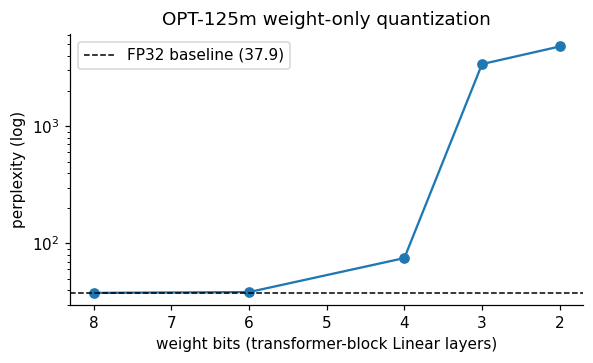

{8: np.float64(37.84), 6: np.float64(38.43), 4: np.float64(75.01), 3: np.float64(3397.24), 2: np.float64(4801.84)}


In [30]:
tok_o = AutoTokenizer.from_pretrained("facebook/opt-125m")
Wo = get_windows(tok_o, 512, 4)
opt32 = AutoModelForCausalLM.from_pretrained("facebook/opt-125m", torch_dtype=torch.float32).eval()

def size_mb(m):
    buf = io.BytesIO(); torch.save(m.state_dict(), buf); return buf.tell() / 1e6

def timed_ppl(m, dev):
    t = time.time(); p = ppl_of(m, Wo, dev); return p, time.time() - t

results = {}
p, t = timed_ppl(opt32, "cpu"); results["FP32 (CPU)"] = (size_mb(opt32), p, t)
try:
    q8 = torch.ao.quantization.quantize_dynamic(copy.deepcopy(opt32), {torch.nn.Linear}, dtype=torch.qint8)
    p, t = timed_ppl(q8, "cpu"); results["INT8 dynamic (CPU)"] = (size_mb(q8), p, t); del q8
except Exception as e:
    print("dynamic INT8 skipped:", repr(e)[:120])
if device == "cuda":
    o16 = copy.deepcopy(opt32).half().to("cuda")
    p, t = timed_ppl(o16, "cuda"); results["FP16 (GPU)"] = (size_mb(o16), p, t); del o16

print(f"{'variant':22}{'size MB':>9}{'perplexity':>12}{'eval s':>8}")
for k, (s_, p_, t_) in results.items(): print(f"{k:22}{s_:>9.0f}{p_:>12.2f}{t_:>8.1f}")

def fake_quant_weights(model, bits):
    qmax = 2 ** (bits - 1) - 1
    with torch.no_grad():
        for m in model.modules():
            if isinstance(m, torch.nn.Linear) and m is not model.lm_head:
                w = m.weight; sc = w.abs().amax(dim=1, keepdim=True).clamp(min=1e-8) / qmax
                m.weight.copy_((w / sc).round().clamp(-qmax, qmax) * sc)

bits_list = [8, 6, 4, 3, 2]; ppls = []
for b in bits_list:
    mq = copy.deepcopy(opt32); fake_quant_weights(mq, b); ppls.append(ppl_of(mq, Wo, "cpu")); del mq
base = results["FP32 (CPU)"][1]
plt.figure(figsize=(5.5, 3.4)); plt.plot(bits_list, ppls, "o-"); plt.axhline(base, color="k", ls="--", lw=1, label=f"FP32 baseline ({base:.1f})")
plt.yscale("log"); plt.gca().invert_xaxis(); plt.xlabel("weight bits (transformer-block Linear layers)"); plt.ylabel("perplexity (log)"); plt.legend(); plt.title("OPT-125m weight-only quantization"); plt.tight_layout(); plt.show()
print(dict(zip(bits_list, np.round(ppls, 2))))
del opt32; free()

## 4) Hooking the attention of a real model + FlashAttention

Modern Hugging Face models call `torch.nn.functional.scaled_dot_product_attention` (SDPA). We **replace that function by our own hook** (a pass-through by default). This lets us (i) capture the real Q/K/V of GPT-2, (ii) recompute attention with our own tiled online-softmax kernel and (iii) change *which* keys each query may attend to inside the real model.

In [31]:
# Install a wrapper around PyTorch's scaled dot-product attention (SDPA).
# By default, the wrapper is a transparent pass-through to the original SDPA implementation.
# When a policy is enabled, it can apply local, sink+local, top-k, or learned-span attention masks.
# Track how many attention pairs are kept versus how many would have been computed normally.
# Optionally capture Q/K/V tensors from a selected layer or build per-layer attention-distance profiles.
# Handle grouped-query attention (GQA) by expanding K/V heads when necessary.
# Replace the functional SDPA entry points so Transformer models using SDPA automatically use the hook.

# =============================================================================
# SDPA HOOK / ATTENTION-POLICY INSTRUMENTATION
# =============================================================================
#
# Purpose
# -------
# This module replaces PyTorch's
# `torch.nn.functional.scaled_dot_product_attention` (SDPA) with a wrapper
# that can operate in several modes:
#
#   1. Pass-through mode
#      When no mode, capture, or profiling operation is requested, the wrapper
#      delegates directly to the original PyTorch SDPA implementation. This
#      keeps the normal execution path unchanged as much as possible.
#
#   2. Attention-policy mode
#      The wrapper can explicitly restrict which key positions each query is
#      allowed to attend to. Supported policies include:
#
#        - "full"
#          Keep every position permitted by the original attention mask.
#
#        - ("local", window)
#          Keep only keys whose distance from the query is smaller than the
#          specified local-attention window.
#
#        - ("sink_local", window, n_sinks)
#          Keep the local attention window plus the first `n_sinks` key
#          positions. The latter are treated as globally accessible
#          "attention sinks".
#
#        - ("topk", k)
#          Compute the attention score matrix explicitly and keep only the
#          highest-scoring `k` keys for each query, subject to the original
#          attention mask.
#
#        - ("span", spans, n_sinks)
#          Use a per-layer/per-head span tensor to determine the local
#          attention range, while always retaining the first `n_sinks` keys.
#
#      The resulting boolean tensor `keep` determines which attention logits
#      participate in the softmax. Disallowed logits are replaced with
#      negative infinity before softmax.
#
#   3. Attention capture
#      A selected SDPA invocation can be captured by layer/call index.
#      Detached float32 copies of Q, K, and V are stored in STATE["captured"].
#      This is useful for inspecting or analyzing the tensors entering SDPA
#      without retaining their autograd graph.
#
#   4. Attention profiling
#      When profiling is enabled, the wrapper measures how attention mass is
#      distributed as a function of query-to-key distance. The first
#      `STATE["sinks"]` key positions are excluded from this profile so that
#      sink-token attention does not dominate the distance statistics.
#
# Grouped-query attention (GQA)
# -----------------------------
# When `enable_gqa=True` and the number of key/value heads differs from the
# number of query heads, K and V are repeated across the head dimension so
# that their head count matches Q. This makes the subsequent explicit
# attention-score computation operate on compatible tensors.
#
# Attention computation
# ---------------------
# Once the hook needs to inspect or modify attention, it explicitly computes:
#
#     S = Q @ K^T * scale
#
# using float32 intermediate values. If no explicit scale is supplied, the
# standard `1 / sqrt(head_dim)` scaling factor is used.
#
# The policy then modifies `keep`, and the final attention weights are
# calculated as:
#
#     softmax(S masked with -inf)
#
# The resulting weights are multiplied by V to produce the SDPA output.
#
# =============================================================================

_ORIG_SDPA = F.scaled_dot_product_attention
STATE = dict(mode=None, layer=0, calls=0, kept=0.0, total=0.0, capture=None, captured=None, profile=None, sinks=4)

def hooked_sdpa(q, k, v, attn_mask=None, dropout_p=0.0, is_causal=False, scale=None, enable_gqa=False, **kw):
    """Pass-through unless STATE asks for a policy / capture / profiling."""
    if STATE["mode"] is None and STATE["capture"] is None and STATE["profile"] is None:
        extra = {"enable_gqa": True} if enable_gqa else {}
        return _ORIG_SDPA(q, k, v, attn_mask=attn_mask, dropout_p=dropout_p, is_causal=is_causal, scale=scale, **extra)

    STATE["calls"] += 1; layer = STATE["layer"]; STATE["layer"] += 1
    if STATE["capture"] == layer: STATE["captured"] = tuple(t.detach().float().clone() for t in (q, k, v))
    if enable_gqa and k.shape[1] != q.shape[1]:
        rep = q.shape[1] // k.shape[1]; k = k.repeat_interleave(rep, 1); v = v.repeat_interleave(rep, 1)
    B, H, Tq, dh = q.shape; Tk = k.shape[2]
    sc = (1.0 / math.sqrt(dh)) if scale is None else scale
    S = (q.float() @ k.float().transpose(-1, -2)) * sc

    if is_causal or attn_mask is None and False:
        allowed = torch.ones(Tq, Tk, dtype=torch.bool, device=q.device).tril(Tk - Tq)[None, None]
    elif attn_mask is None:
        allowed = torch.ones(1, 1, Tq, Tk, dtype=torch.bool, device=q.device)
    elif attn_mask.dtype == torch.bool:
        allowed = attn_mask
    else:
        allowed = attn_mask.float() > -1e4
    while allowed.dim() < 4: allowed = allowed[None]
    keep = allowed.expand(B, H, Tq, Tk)

    mode = STATE["mode"]
    ii = (torch.arange(Tq, device=q.device)[:, None] + (Tk - Tq)); jj = torch.arange(Tk, device=q.device)[None, :]
    dist = ii - jj                                                          # query pos - key pos (>=0 if causal)
    if mode is not None:
        kind = mode[0]
        if kind == "local":                                                 # ("local", w)
            keep = keep & (dist < mode[1])[None, None]
        elif kind == "sink_local":                                          # ("sink_local", w, n_sinks)
            keep = keep & ((dist < mode[1]) | (jj < mode[2]))[None, None]
        elif kind == "topk":                                                # ("topk", k)
            Sm = S.masked_fill(~keep, float("-inf"))
            thr = Sm.topk(min(mode[1], Tk), dim=-1).values[..., -1:]
            keep = keep & (Sm >= thr)
        elif kind == "span":                                                # ("span", spans[L,H], n_sinks)
            sp = mode[1][layer].to(q.device).view(1, H, 1, 1)
            keep = keep & ((dist[None, None] < sp) | (jj < mode[2])[None, None])
        elif kind != "full":
            raise ValueError(kind)
    STATE["kept"] += keep.sum().item(); STATE["total"] += allowed.expand(B, H, Tq, Tk).sum().item()

    W = torch.softmax(S.masked_fill(~keep, float("-inf")), dim=-1)
    if STATE["profile"] is not None:                                        # distance profile of attention mass (sinks excluded)
        Wp = W.clone(); Wp[..., :STATE["sinks"]] = 0
        D = dist.clamp(min=0).reshape(1, -1).expand(H, -1).contiguous()
        prof = torch.zeros(H, Tk, device=q.device).scatter_add_(1, D, Wp.sum(0).reshape(H, -1))
        STATE["profile"][layer] = STATE["profile"].get(layer, 0) + prof
    return (W.to(v.dtype) @ v)

F.scaled_dot_product_attention = hooked_sdpa
torch.nn.functional.scaled_dot_product_attention = hooked_sdpa

def reset_state(**kw):
    STATE.update(mode=None, layer=0, calls=0, kept=0.0, total=0.0, capture=None, captured=None, profile=None); STATE.update(kw)
print("SDPA hook installed (pass-through by default).")

SDPA hook installed (pass-through by default).


In [32]:
# Capture real fp32 Q/K/V from GPT-2 at layer 6, then validate a custom
# tiled attention implementation against PyTorch's fused SDPA.
#
# The custom attention uses 128x128 Q/K/V tiles, causal masking, and an
# online softmax update so the full 1024x1024 attention-score matrix is
# never materialized.
#
# The running max (m) and normalization term (l) allow each tile to be
# accumulated exactly as part of one global softmax rather than applying
# softmax independently to each tile.
#
# Finally, several GPT-2 heads are compared against the original fused
# SDPA output. Differences should be at normal fp32 round-off level.

# real Q/K/V from GPT-2 (fp32), captured at layer 6, + our own tiled online-softmax attention
tok_g = AutoTokenizer.from_pretrained("gpt2")
gpt32 = AutoModelForCausalLM.from_pretrained("gpt2", torch_dtype=torch.float32, attn_implementation="sdpa").to(device).eval()
w0 = get_windows(tok_g, 1024, 1)[0][None].to(device)
reset_state(capture=6, mode=("full",))
with torch.no_grad(): gpt32(w0)
assert STATE["captured"] is not None, "hook did not fire: this transformers version does not route GPT-2 through F.scaled_dot_product_attention"
q, k, v = STATE["captured"]; reset_state()
print("captured Q/K/V:", tuple(q.shape))

def flash_torch(Q, K, V, Br=128, Bc=128, causal=True):
    T, d = Q.shape; dev = Q.device
    O = torch.zeros_like(Q); m = torch.full((T,), float("-inf"), device=dev); l = torch.zeros(T, device=dev)
    for j in range(0, T, Bc):                                   # outer loop: K/V blocks ("loaded into SRAM")
        Kj, Vj = K[j:j+Bc], V[j:j+Bc]
        for i in range(0, T, Br):                               # inner loop: Q blocks
            Qi = Q[i:i+Br]; S = Qi @ Kj.T / math.sqrt(d)
            if causal:
                qi = torch.arange(i, i + Qi.shape[0], device=dev)[:, None]; kj = torch.arange(j, j + Kj.shape[0], device=dev)[None]
                S = S.masked_fill(kj > qi, float("-inf"))
            m_new = torch.maximum(m[i:i+Br], S.max(1).values)
            m_safe = torch.where(torch.isfinite(m_new), m_new, torch.zeros_like(m_new))
            P = torch.exp(S - m_safe[:, None]); sc = torch.exp(m[i:i+Br] - m_safe)
            l[i:i+Br] = sc * l[i:i+Br] + P.sum(1)                              # Eq. (8)
            O[i:i+Br] = sc[:, None] * O[i:i+Br] + P @ Vj; m[i:i+Br] = m_new
    return O / l[:, None]

ref = _ORIG_SDPA(q, k, v, is_causal=True)[0]                                   # PyTorch's fused kernel, all heads
print(f"{'head':>5} {'max |ours - torch SDPA|':>25}")
for h_ in [0, 3, 7, 11]:
    ours = flash_torch(q[0, h_], k[0, h_], v[0, h_], 128, 128)
    print(f"{h_:>5} {(ours - ref[h_]).abs().max().item():>25.2e}")
print("-> exact (fp32 round-off): tiling + online softmax never builds the 1024x1024 matrix, yet reproduces real GPT-2 attention.")

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (18219 > 1024). Running this sequence through the model will result in indexing errors


captured Q/K/V: (1, 12, 1024, 64)
 head   max |ours - torch SDPA|
    0                  4.77e-07
    3                  4.77e-07
    7                  9.54e-07
   11                  5.96e-07
-> exact (fp32 round-off): tiling + online softmax never builds the 1024x1024 matrix, yet reproduces real GPT-2 attention.


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

max |eager - SDPA| hidden state (torch.float16): 3.75e-01
     T | eager:      s   peak MB | sdpa:      s   peak MB
   256 |         0.040       156 |        0.029       142
   512 |         0.082       338 |        0.059       284
  1024 |         0.211       798 |        0.122       568


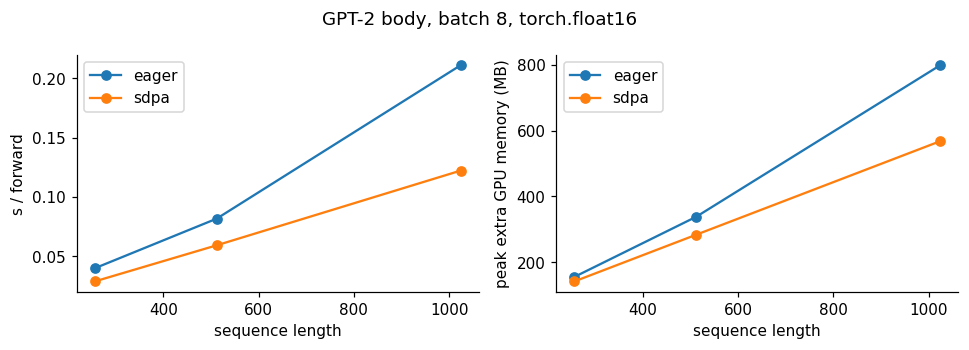

Note: a T4 (sm75) has no FlashAttention-2 kernel; SDPA then uses the memory-efficient (xformers-style) tiled kernel — same idea.


In [33]:
# =============================================================================
# GPT-2 Eager Attention vs. SDPA Benchmark
# =============================================================================
#
# Description:
# This experiment compares two attention implementations used by the real
# GPT-2 transformer body:
#
#   - eager:
#       Explicit attention computation using the standard PyTorch/Hugging Face
#       eager implementation.
#
#   - sdpa:
#       PyTorch's scaled dot-product attention (SDPA), which can select a
#       fused or memory-efficient attention kernel depending on the available
#       hardware and PyTorch configuration.
#
# The benchmark compares the implementations in three ways:
#
#   1. Numerical agreement:
#      The maximum absolute difference between the hidden states produced by
#      eager attention and SDPA is measured on the same random input.
#
#   2. Forward-pass execution time:
#      Average forward-pass time is measured for several sequence lengths.
#
#   3. Peak additional GPU memory:
#      On CUDA, peak memory allocated during the forward pass is measured for
#      each attention implementation.
#
# Sequence lengths and batch size are selected according to the available
# device:
#   - CUDA: batch size 8 with sequence lengths 256, 512, and 1024.
#   - CPU: batch size 1 with sequence lengths 128, 256, and 512.
#
# A warm-up forward pass is performed before timing to reduce first-run
# initialization effects.
#
# On CUDA, the benchmark also produces plots comparing:
#   - Forward-pass time versus sequence length.
#   - Peak additional GPU memory versus sequence length.
#
# The numerical comparison verifies that switching from eager attention to SDPA
# preserves the model's output up to normal floating-point differences.
#
# Note:
# The exact SDPA kernel selected depends on the GPU architecture and PyTorch
# configuration. Some older GPUs do not support the FlashAttention-2 kernel,
# so SDPA may instead select another memory-efficient/tiled implementation.
#
# Required variables/functions:
#   - DTYPE
#   - device
#   - sync()
#   - free()
#   - torch
#   - time
#   - matplotlib.pyplot as plt
#
# =============================================================================

# eager vs SDPA (fused, memory-efficient / flash kernel): memory and time on the real GPT-2 body
def load_body(impl):
    return AutoModelForCausalLM.from_pretrained("gpt2", torch_dtype=DTYPE, attn_implementation=impl).to(device).eval().transformer

def bench(body, B, T, reps=3):
    ids = torch.randint(0, 50000, (B, T), device=device)
    with torch.inference_mode():
        body(ids); sync()
        if device == "cuda": torch.cuda.reset_peak_memory_stats(); base = torch.cuda.memory_allocated()
        t = time.time()
        for _ in range(reps): body(ids)
        sync(); dt = (time.time() - t) / reps
    peak = (torch.cuda.max_memory_allocated() - base) / 1e6 if device == "cuda" else float("nan")
    return dt, peak

body_e, body_s = load_body("eager"), load_body("sdpa")
x = torch.randint(0, 50000, (2, 256), device=device)
with torch.inference_mode():
    d_ = (body_e(x).last_hidden_state.float() - body_s(x).last_hidden_state.float()).abs().max().item()
print(f"max |eager - SDPA| hidden state ({DTYPE}): {d_:.2e}")

Ts, B = ([256, 512, 1024], 8) if device == "cuda" else ([128, 256, 512], 1)
R = {impl: [bench(b_, B, T) for T in Ts] for impl, b_ in [("eager", body_e), ("sdpa", body_s)]}
print(f"{'T':>6} | eager: {'s':>6} {'peak MB':>9} | sdpa: {'s':>6} {'peak MB':>9}")
for i, T in enumerate(Ts): print(f"{T:>6} |        {R['eager'][i][0]:>6.3f} {R['eager'][i][1]:>9.0f} |       {R['sdpa'][i][0]:>6.3f} {R['sdpa'][i][1]:>9.0f}")
if device == "cuda":
    fig, ax = plt.subplots(1, 2, figsize=(9, 3.2))
    for impl in R:
        ax[0].plot(Ts, [r[0] for r in R[impl]], "o-", label=impl); ax[1].plot(Ts, [r[1] for r in R[impl]], "o-", label=impl)
    ax[0].set_ylabel("s / forward"); ax[1].set_ylabel("peak extra GPU memory (MB)")
    for a_ in ax: a_.set_xlabel("sequence length"); a_.legend()
    plt.suptitle(f"GPT-2 body, batch {B}, {DTYPE}"); plt.tight_layout(); plt.show()
    print("Note: a T4 (sm75) has no FlashAttention-2 kernel; SDPA then uses the memory-efficient (xformers-style) tiled kernel — same idea.")
del body_e, body_s; free()

## 5) Dynamic and learned sparsity on a real language model

We now change **which keys each query may attend to inside pretrained GPT-2** (no retraining) and measure perplexity on WikiText-2 (1024-token windows). *Density* = fraction of the causal query–key pairs that are still computed.

Policies:
* `local(w)` — fixed sliding window
* `sink+local(w)` — window plus the first 4 tokens as *global* tokens (Longformer/BigBird-style global attention)
* `top-k(k)` — each query keeps only its k highest-scoring keys (Explicit Sparse Transformer): **input-dependent**
* `per-head span` — each head gets its own window, **calibrated** from how far that head actually looks (adaptive span; here without training the span with a penalty, as Sukhbaatar et al. do)

In [34]:
# =============================================================================
# GPT-2 Baseline Perplexity and Attention-Hook Verification
# =============================================================================
#
# Description:
# This experiment evaluates a GPT-2 model using fixed-length token windows and
# verifies that the custom attention hook correctly observes the model's
# attention computation.
#
# The model is assumed to already be loaded in FP32 and to use the SDPA
# attention implementation.
#
# The evaluation text is divided into six windows of 1024 tokens:
#   - The first two windows are used for calibration.
#   - The remaining four windows are used for evaluation.
#
# Two perplexity measurements are computed:
#   1. Unhooked baseline:
#      Perplexity is measured directly using the standard GPT-2 forward pass.
#
#   2. Hooked full-attention evaluation:
#      The custom attention hook is enabled in "full" mode while leaving the
#      attention computation unchanged.
#
# The two perplexity values should closely match. This provides a sanity check
# that the attention-hook mechanism does not alter the model's behavior when
# full attention is requested.
#
# The evaluation also tracks:
#   - Number of attention positions kept by the hook.
#   - Total number of attention positions considered.
#   - Resulting attention density.
#   - Number of times the attention hook is called.
#
# An assertion verifies that the hook is invoked once per transformer layer
# for every evaluation window. This confirms that the expected SDPA execution
# path is being used.
#
# Required variables/functions:
#   - gpt32 / gpt
#   - tok_g
#   - get_windows()
#   - reset_state()
#   - STATE
#   - ppl_of()
#   - F.cross_entropy()
#   - torch
#   - math
#   - device
#
# =============================================================================

gpt = gpt32                      # fp32 GPT-2 (SDPA), already loaded
W6 = get_windows(tok_g, 1024, 6); W_cal, W_eval = W6[:2], W6[2:]

def eval_mode(mode, windows, model=gpt):
    reset_state(mode=mode); nll = 0.0; cnt = 0
    for w in windows:
        STATE["layer"] = 0; ids = w[None].to(device)
        with torch.no_grad(): logits = model(ids).logits.float()
        nll += F.cross_entropy(logits[0, :-1], ids[0, 1:], reduction="sum").item(); cnt += ids.shape[1] - 1
    assert STATE["calls"] == model.config.num_hidden_layers * len(windows), f"hook fired {STATE['calls']} times — SDPA path not used"
    dens = STATE["kept"] / STATE["total"]; reset_state()
    return math.exp(nll / cnt), dens

plain = ppl_of(gpt, W_eval); hooked, d_ = eval_mode(("full",), W_eval)
print(f"baseline perplexity (unhooked): {plain:.3f} | through my hook, full attention: {hooked:.3f}  (should match)")

baseline perplexity (unhooked): 36.398 | through my hook, full attention: 36.398  (should match)


In [35]:
# =============================================================================
# Sparse Attention Policy Benchmark
# =============================================================================
#
# Description:
# This experiment evaluates several sparse-attention policies on the GPT-2
# evaluation windows and measures the trade-off between attention density and
# language-model perplexity.
#
# The following attention policies are compared:
#   - local(w):
#       Each query attends only to a local window of size w.
#
#   - sink+local(w):
#       Combines a local attention window with a fixed number of global
#       attention sink tokens.
#
#   - top-k(k):
#       Each query retains only its k highest-scoring attention positions.
#
# For every configuration, `eval_mode()` returns:
#   - Perplexity: language-model prediction loss expressed as perplexity.
#   - Density: fraction of the full causal attention positions that are kept.
#
# The results are stored in `curves` so they can be reused later for plotting
# the sparsity/perplexity trade-off.
#
# The printed table reports the policy, its span or k parameter, attention
# density, and resulting perplexity.
#
# Required variables/functions:
#   - W_eval
#   - eval_mode()
#   - gpt
#
# Expected modes:
#   - ("local", w)
#   - ("sink_local", w, number_of_sinks)
#   - ("topk", k)
#
# =============================================================================

grid_w = [8, 16, 32, 64, 128, 256, 512]
curves = {"local(w)": [eval_mode(("local", w), W_eval) for w in grid_w],
          "sink+local(w)": [eval_mode(("sink_local", w, 4), W_eval) for w in grid_w],
          "top-k(k)": [eval_mode(("topk", k), W_eval) for k in [2, 4, 8, 16, 32, 64, 128]]}
print(f"{'policy':16}{'param':>7}{'density':>9}{'perplexity':>12}")
for (nm, pts), params in zip(curves.items(), [grid_w, grid_w, [2, 4, 8, 16, 32, 64, 128]]):
    for prm, (p_, d_) in zip(params, pts): print(f"{nm:16}{prm:>7}{d_:>9.1%}{p_:>12.2f}")

policy            param  density  perplexity
local(w)              8     1.6%   145898.82
local(w)             16     3.1%    67483.94
local(w)             32     6.1%    26354.01
local(w)             64    12.1%    12912.72
local(w)            128    23.4%     6159.30
local(w)            256    43.7%     1492.04
local(w)            512    75.0%      121.20
sink+local(w)         8     2.3%      445.23
sink+local(w)        16     3.9%      220.66
sink+local(w)        32     6.9%      126.84
sink+local(w)        64    12.8%       81.33
sink+local(w)       128    24.1%       60.79
sink+local(w)       256    44.3%       46.26
sink+local(w)       512    75.4%       37.86
top-k(k)              2     0.4%     1114.00
top-k(k)              4     0.8%      393.16
top-k(k)              8     1.6%      161.41
top-k(k)             16     3.1%       72.59
top-k(k)             32     6.1%       43.16
top-k(k)             64    12.1%       37.33
top-k(k)            128    23.4%       36.41


### 5.1 How far does each head really look? (the motivation for adaptive span)
We record, for every layer and head, the distribution of attention mass over the **query–key distance** on the calibration windows. (The 4 sink tokens are excluded, because heads park a lot of mass on the first token regardless of distance.) The span of a head = the smallest window that contains *p* % of its remaining mass.

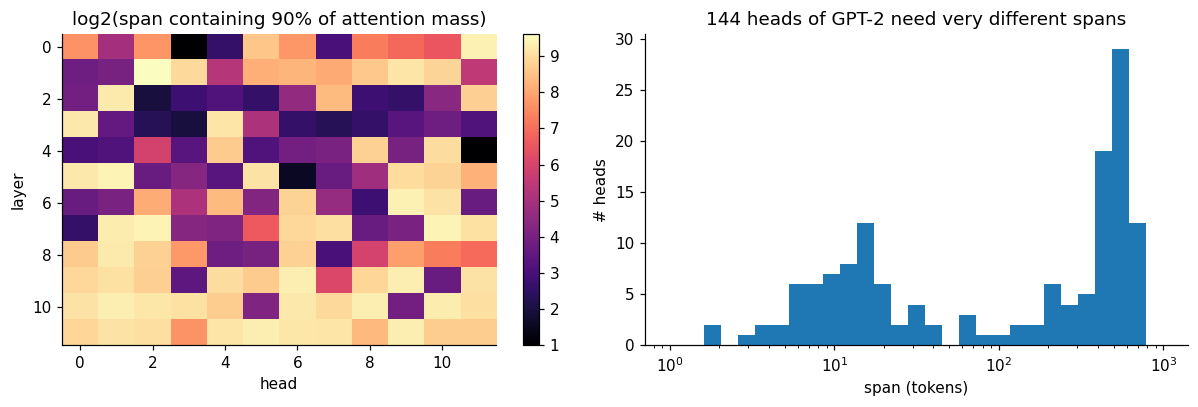

span@90%: min 2, median 207, max 779 tokens  |  heads needing <=16 tokens: 43/144


In [36]:
# =============================================================================
# GPT-2 Attention Profile Calibration and Adaptive Span Analysis
# =============================================================================
#
# Description:
# This experiment profiles the attention distributions of a GPT-2 model across
# multiple calibration sequences and uses the collected attention statistics
# to estimate an appropriate attention span for each layer and attention head.
#
# The profiling process:
#   - Resets the model to full attention mode.
#   - Runs the model over the calibration dataset.
#   - Collects attention profiles for each transformer layer.
#   - Stores the resulting profiles for later span estimation.
#
# The `spans_from_profile()` function converts an attention profile into a
# token span that contains a specified fraction of the total attention mass.
# For example, p=0.90 selects the smallest prefix of tokens containing
# approximately 90% of the attention probability.
#
# The analysis then visualizes the spans required to capture 90% of attention
# mass across all GPT-2 layers and attention heads.
#
# The two visualizations show:
#   1. A heatmap of log2 attention spans for every layer/head combination.
#   2. A histogram showing the distribution of required attention spans.
#
# The final summary reports:
#   - Minimum span across all heads.
#   - Median span across all heads.
#   - Maximum span across all heads.
#   - Number of heads whose 90%-mass span is at most 16 tokens.
#
# Required variables/functions:
#   - W_cal
#   - STATE
#   - reset_state()
#   - gpt
#   - torch
#   - np
#   - plt
#   - device
#
# The resulting profile can be used to construct adaptive sparse-attention
# configurations in later experiments.
#
# =============================================================================

reset_state(mode=("full",), profile={})
for w in W_cal:
    STATE["layer"] = 0
    with torch.no_grad(): gpt(w[None].to(device))
prof = {l: t.cpu() for l, t in STATE["profile"].items()}; reset_state()

def spans_from_profile(prof, p):
    Ls = len(prof); Hh = prof[0].shape[0]; sp = torch.zeros(Ls, Hh)
    for l in range(Ls):
        P = prof[l] / prof[l].sum(-1, keepdim=True); sp[l] = (P.cumsum(-1) < p).sum(-1).float() + 1
    return sp

sp90 = spans_from_profile(prof, 0.90)
fig, ax = plt.subplots(1, 2, figsize=(11, 3.8))
im = ax[0].imshow(np.log2(sp90.numpy()), cmap="magma", aspect="auto"); ax[0].set_xlabel("head"); ax[0].set_ylabel("layer")
ax[0].set_title("log2(span containing 90% of attention mass)"); plt.colorbar(im, ax=ax[0])
ax[1].hist(sp90.flatten().numpy(), bins=np.logspace(0, 3, 30)); ax[1].set_xscale("log"); ax[1].set_xlabel("span (tokens)"); ax[1].set_ylabel("# heads"); ax[1].set_title("144 heads of GPT-2 need very different spans")
plt.tight_layout(); plt.show()
print(f"span@90%: min {sp90.min():.0f}, median {sp90.median():.0f}, max {sp90.max():.0f} tokens  |  heads needing <=16 tokens: {(sp90<=16).sum().item()}/144")

 mass p  mean span  density  perplexity
   0.50       61.0    11.7%      149.30
   0.70      133.6    22.9%       52.89
   0.80      187.6    30.4%       41.50
   0.90      266.7    39.8%       37.70
   0.95      340.1    47.8%       37.03
   0.99      498.2    62.8%       36.39


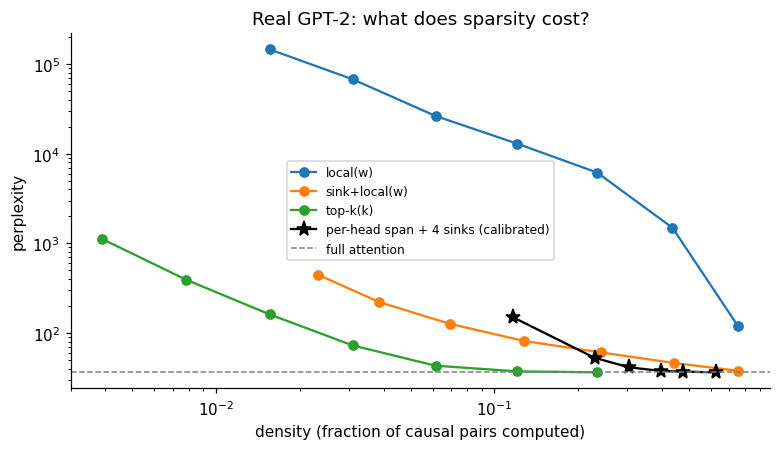

In [37]:
# =============================================================================
# Adaptive Span Evaluation and Sparsity–Perplexity Trade-off
# =============================================================================
#
# Description:
# This experiment evaluates an adaptive attention-span strategy for a language
# model. Different probability-mass thresholds are used to determine how much
# of each attention profile should be retained.
#
# For each mass threshold p, the code:
#   - Converts the attention profile into an adaptive span.
#   - Evaluates the resulting sparse attention pattern.
#   - Measures the fraction of causal attention pairs that remain active.
#   - Measures the resulting language-model perplexity.
#   - Records the mean attention span across the evaluated profiles.
#
# The experiment compares the adaptive span configurations against previously
# measured sparsity/perplexity curves stored in `curves`.
#
# The final plot uses logarithmic axes to show the trade-off between:
#   - Attention density: fraction of causal attention pairs computed.
#   - Perplexity: language-model prediction quality.
#
# The full-attention perplexity is shown as a horizontal reference line.
# Adaptive span results are plotted separately using the label:
#   "per-head span + 4 sinks (calibrated)"
#
# Parameters:
#   p : cumulative attention-mass threshold used to determine each span.
#
# Required variables/functions:
#   - prof
#   - spans_from_profile()
#   - eval_mode()
#   - W_eval
#   - curves
#   - plain
#
# Output:
#   - A table containing mass threshold, mean span, density, and perplexity.
#   - A log-log sparsity versus perplexity plot.
#
# =============================================================================

adapt = []
for p in [0.5, 0.7, 0.8, 0.9, 0.95, 0.99]:
    sp = spans_from_profile(prof, p); ppl_, dens_ = eval_mode(("span", sp, 4), W_eval); adapt.append((p, dens_, ppl_, sp.mean().item()))
print(f"{'mass p':>7}{'mean span':>11}{'density':>9}{'perplexity':>12}")
for p, d_, pp_, ms in adapt: print(f"{p:>7.2f}{ms:>11.1f}{d_:>9.1%}{pp_:>12.2f}")

fig, ax = plt.subplots(figsize=(7.2, 4.2))
for nm, pts in curves.items(): ax.plot([d for _, d in pts], [p for p, _ in pts], "o-", label=nm)
ax.plot([a[1] for a in adapt], [a[2] for a in adapt], "k*-", ms=10, label="per-head span + 4 sinks (calibrated)")
ax.axhline(plain, color="gray", ls="--", lw=1, label="full attention")
ax.set_xscale("log"); ax.set_yscale("log"); ax.set_xlabel("density (fraction of causal pairs computed)"); ax.set_ylabel("perplexity"); ax.legend(fontsize=8)
ax.set_title("Real GPT-2: what does sparsity cost?"); plt.tight_layout(); plt.show()

**Look for:** (1) how much worse a plain fixed window is than the same window *plus sink tokens*; (2) whether `top-k` (input-dependent) or the per-head calibrated span reaches full-attention perplexity at lower density than the uniform windows; (3) the wide spread of head spans in the heat-map, the empirical reason to give every head its *own* span instead of one global window. This is post-hoc masking of a model that was **trained with full attention**; models trained with the sparsity in the loop (Longformer, adaptive span, entmax) are expected to do better than what you see here.

In [38]:
# Release the GPT model references and reclaim Python/GPU memory.
del gpt, gpt32; free()

## 6) Token merging (ToMe) inside a real Vision Transformer

`google/vit-base-patch16-224` has 197 tokens (196 patches + `[CLS]`). We re-implement the forward pass layer by layer using the model's own weights and insert **bipartite soft matching** after each attention block: the *r* most similar token pairs (cosine similarity of the attention *keys*) are merged by size-weighted averaging, and attention gets a `+log(size)` bias (*proportional attention*). Baseline: dropping *r* random patch tokens per layer. No retraining. We measure top-1 agreement with the unmodified model and throughput.

In [39]:
# =============================================================================
# Vision Transformer Token Merging and Random Token Dropping
# =============================================================================
#
# Description:
# This script loads a pretrained Vision Transformer (ViT) and implements a
# custom forward pass that allows tokens to be reduced during transformer
# processing.
#
# Two token-reduction strategies are implemented:
#   - Bipartite token merging:
#       Similar tokens are paired and merged using a similarity-based matching
#       strategy. The [CLS] token is preserved and is never merged.
#
#   - Random token dropping:
#       Tokens are randomly removed while preserving the [CLS] token.
#
# The script also reproduces the Hugging Face ViT forward pass manually. This
# makes it possible to insert token reduction between transformer layers while
# keeping the standard attention, residual, LayerNorm, and MLP operations.
#
# Token sizes are tracked throughout the network so that merged tokens retain
# information about the number of original tokens represented by each merged
# token.
#
# The script uses a small image dataset for testing. If Tiny ImageNet cannot
# be loaded, a COCO image is repeated as a fallback.
#
# Main components:
#   - get_images():
#       Loads test images from Tiny ImageNet or a fallback COCO image.
#
#   - bipartite_merge():
#       Merges similar pairs of tokens while preserving token-size information.
#
#   - random_drop():
#       Randomly removes tokens while keeping the [CLS] token.
#
#   - vit_forward():
#       Performs a manual ViT forward pass with optional token reduction.
#
# Verification:
# The custom forward pass is first compared against the original Hugging Face
# ViT implementation with r=0. This sanity check ensures that the custom
# implementation produces nearly identical logits before token reduction is
# introduced.
#
# Requirements:
#   - PyTorch
#   - Transformers
#   - NumPy
#   - Matplotlib
#   - Hugging Face Datasets
#   - Requests
#   - Pillow
#
# Model:
#   google/vit-base-patch16-224
#
# Notes:
#   - The model expects 224 x 224 image inputs.
#   - ViT-B/16 produces 196 image patch tokens plus one [CLS] token.
#   - The token-reduction parameter r controls the number of tokens reduced
#     at each transformer layer.
#
# =============================================================================

from transformers import ViTForImageClassification, ViTImageProcessor
proc = ViTImageProcessor.from_pretrained("google/vit-base-patch16-224")
vit = ViTForImageClassification.from_pretrained("google/vit-base-patch16-224", attn_implementation="eager").to(device).eval()

def get_images(n=64):
    try:
        from datasets import load_dataset
        ds = load_dataset("zh-plus/tiny-imagenet", split=f"valid[:{n}]")
        return [im.convert("RGB") for im in ds["image"]]
    except Exception as e:
        print("tiny-imagenet unavailable (", repr(e)[:80], ") -> using the COCO cats image repeated")
        import requests; from PIL import Image
        img = Image.open(requests.get("http://images.cocodataset.org/val2017/000000039769.jpg", stream=True).raw).convert("RGB")
        return [img] * 16

imgs = get_images(64)
pix = proc(images=imgs, return_tensors="pt").pixel_values.to(device)
print("images:", pix.shape)

def bipartite_merge(x, size, metric, r):
    B, N, C = x.shape
    r = min(r, (N + 1) // 2 - 1)
    if r <= 0: return x, size
    m = metric / metric.norm(dim=-1, keepdim=True)
    a, b = m[:, ::2], m[:, 1::2]
    scores = a @ b.transpose(-1, -2)
    scores[:, 0, :] = -math.inf                                   # never merge [CLS]
    node_max, node_idx = scores.max(-1)
    edge_idx = node_max.argsort(-1, descending=True)[..., None]
    unm_idx = edge_idx[:, r:].sort(dim=1)[0]; src_idx = edge_idx[:, :r]
    dst_idx = node_idx[..., None].gather(1, src_idx)
    def merge(t):
        src, dst = t[:, ::2], t[:, 1::2]; Cc = t.shape[-1]
        unm = src.gather(1, unm_idx.expand(-1, -1, Cc)); srcm = src.gather(1, src_idx.expand(-1, -1, Cc))
        dst = dst.scatter_add(1, dst_idx.expand(-1, -1, Cc), srcm)
        return torch.cat([unm, dst], 1)
    xs = merge(x * size); size2 = merge(size)
    return xs / size2, size2

def random_drop(x, size, r):
    B, N, C = x.shape; r = min(r, N - 2)
    if r <= 0: return x, size
    idx = (torch.rand(B, N - 1, device=x.device).argsort(-1)[:, : N - 1 - r] + 1).sort(-1)[0]
    idx = torch.cat([torch.zeros(B, 1, dtype=torch.long, device=x.device), idx], 1)[..., None]
    return x.gather(1, idx.expand(-1, -1, C)), size.gather(1, idx)

def vit_forward(model, px, r=0, mode="merge"):
    H = model.config.num_attention_heads

    x = model.vit.embeddings(px)
    B, N, C = x.shape

    size = torch.ones(
        B, N, 1,
        device=x.device,
        dtype=x.dtype
    )

    for layer in model.vit.layers:
        # Pre-attention LayerNorm
        h = layer.layernorm_before(x)

        att = layer.attention
        n_ = x.shape[1]

        # New HF ViT uses q_proj/k_proj/v_proj/o_proj
        qh = att.q_proj(h)
        kh = att.k_proj(h)
        vh = att.v_proj(h)

        # [B, N, C] -> [B, H, N, head_dim]
        qh = qh.view(B, n_, H, C // H).transpose(1, 2)
        kh = kh.view(B, n_, H, C // H).transpose(1, 2)
        vh = vh.view(B, n_, H, C // H).transpose(1, 2)

        # Attention scores
        s = qh @ kh.transpose(-1, -2)
        s = s / math.sqrt(C // H)

        if mode == "merge":
            s = s + size.log().transpose(1, 2)[:, None]

        # Attention
        o = s.softmax(-1) @ vh

        # [B, H, N, head_dim] -> [B, N, C]
        o = o.transpose(1, 2).reshape(B, n_, C)

        # Output projection + residual
        x = x + att.o_proj(o)

        # Token reduction
        if r > 0:
            if mode == "merge":
                x, size = bipartite_merge(
                    x, size, kh.mean(1), r
                )
            else:
                x, size = random_drop(x, size, r)

        # MLP block
        h = layer.layernorm_after(x)
        h = layer.mlp(h)

        # Residual
        x = x + h

    x = model.vit.layernorm(x)

    return model.classifier(x[:, 0]), x.shape[1]

with torch.no_grad():
    ref_logits = vit(pix[:8]).logits; mine, _ = vit_forward(vit, pix[:8], r=0)
print(f"sanity: max |HF forward - my forward| (r=0) = {(ref_logits - mine).abs().max().item():.2e}   (must be ~1e-4 or smaller)")
assert (ref_logits - mine).abs().max().item() < 1e-2, "re-implemented ViT forward does not match the HF model in this version"

preprocessor_config.json:   0%|          | 0.00/160 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/69.7k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  346MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

...

data/valid-00000-of-00001-70d52db3c749a9(…): reconstructing file:   0%|          |  0.00B / 14.6MB            

data/valid-00000-of-00001-70d52db3c749a9(…): downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/100000 [00:00<?, ? examples/s]

Generating valid split:   0%|          | 0/10000 [00:00<?, ? examples/s]

images: torch.Size([64, 3, 224, 224])
sanity: max |HF forward - my forward| (r=0) = 0.00e+00   (must be ~1e-4 or smaller)


baseline throughput: 85 img/s
 r/layer final tokens |  ToMe agree   img/s |  random-drop agree   img/s
       0          197 |      100.0%      93 |             100.0%      93
       4          149 |       95.3%      97 |              95.3%     103
       8          101 |       90.6%     117 |              92.2%     120
      12           53 |       87.5%     138 |              90.6%     140
      16           11 |       87.5%     171 |              87.5%     177


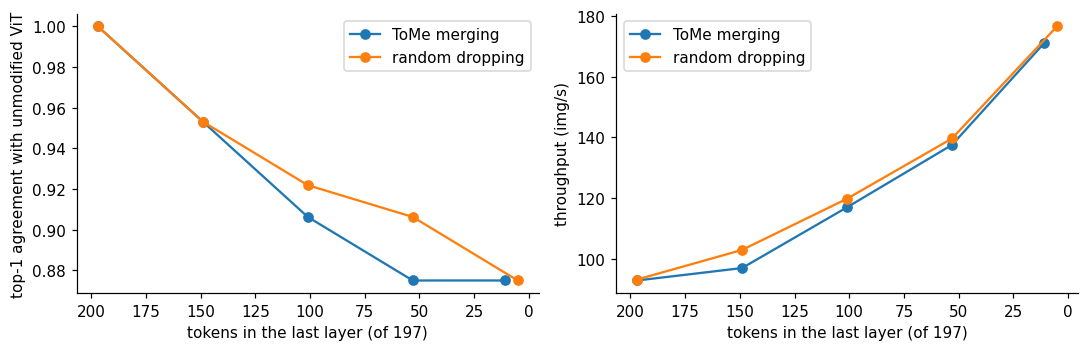

In [40]:
# =============================================================================
# Vision Transformer Token Reduction Benchmark
# =============================================================================
#
# Description:
# This script evaluates the effect of reducing the number of tokens processed
# by a Vision Transformer (ViT) on prediction agreement and inference
# throughput.
#
# Two token-reduction strategies are compared:
#   - ToMe merging:
#       Reduces the token count by merging similar tokens.
#
#   - Random dropping:
#       Reduces the token count by randomly removing tokens.
#
# The experiment evaluates several reduction levels and compares each modified
# model configuration against the predictions of the unmodified ViT.
#
# For each configuration, the script measures:
#   - Top-1 prediction agreement with the baseline ViT.
#   - Inference throughput in images per second.
#   - Number of tokens remaining in the final transformer layer.
#
# The baseline configuration uses r=0 token reduction with the "merge" mode.
# The same set of reduction levels is then evaluated using both merging and
# random token dropping.
#
# The first plot shows prediction agreement as the number of final-layer tokens
# decreases. The second plot shows the corresponding inference throughput.
#
# The x-axis is inverted so that stronger token reduction appears toward the
# left side of the plots.
#
# Parameters:
#   r  : number of tokens reduced per layer.
#   mode : token reduction strategy ("merge" or "drop").
#   bs : inference batch size.
#
# Requirements:
#   - PyTorch
#   - NumPy
#   - Matplotlib
#   - A pretrained ViT model and token-reduction implementation.
#
# Assumptions:
#   - pix contains the input image tensors.
#   - vit is the pretrained Vision Transformer.
#   - vit_forward() performs model inference with token reduction.
#   - sync() synchronizes the accelerator before timing.
#   - torch, time, and matplotlib.pyplot (plt) are already imported.
#
# =============================================================================

def run_all(r, mode, bs=32):
    preds, t = [], 0.0
    with torch.inference_mode():
        for i in range(0, len(pix), bs):
            sync(); t0 = time.time(); lg, n_final = vit_forward(vit, pix[i:i+bs], r, mode); sync(); t += time.time() - t0
            preds.append(lg.argmax(-1).cpu())
    return torch.cat(preds), len(pix) / t, n_final

base_pred, base_ips, _ = run_all(0, "merge")
rs = [0, 4, 8, 12, 16]
table = {m: [run_all(r, m) for r in rs] for m in ["merge", "drop"]}
print(f"baseline throughput: {base_ips:.0f} img/s")
print(f"{'r/layer':>8}{'final tokens':>13} | {'ToMe agree':>11}{'img/s':>8} | {'random-drop agree':>18}{'img/s':>8}")
for i, r in enumerate(rs):
    pm, im_, nf = table["merge"][i]; pd_, id_, _ = table["drop"][i]
    print(f"{r:>8}{nf:>13} | {(pm==base_pred).float().mean():>11.1%}{im_:>8.0f} | {(pd_==base_pred).float().mean():>18.1%}{id_:>8.0f}")

fig, ax = plt.subplots(1, 2, figsize=(10, 3.3))
for m, lab in [("merge", "ToMe merging"), ("drop", "random dropping")]:
    ax[0].plot([table[m][i][2] for i in range(len(rs))], [(table[m][i][0] == base_pred).float().mean().item() for i in range(len(rs))], "o-", label=lab)
    ax[1].plot([table[m][i][2] for i in range(len(rs))], [table[m][i][1] for i in range(len(rs))], "o-", label=lab)
for a_, yl in zip(ax, ["top-1 agreement with unmodified ViT", "throughput (img/s)"]):
    a_.invert_xaxis(); a_.set_xlabel("tokens in the last layer (of 197)"); a_.set_ylabel(yl); a_.legend()
plt.tight_layout(); plt.show()

**Look for:** how quickly agreement drops for random dropping vs. merging at the same number of remaining tokens, and how throughput rises as tokens shrink. Note that `tiny-imagenet` images are only 64×64 up-sampled to 224 and its classes only partially overlap ImageNet-1k, so we compare *against the unmodified model* rather than against ground truth.

## 8) Interpretability on real models: rollout and flow

### 7.1 Attention rollout on ViT
Head-averaged attention with the residual connection added (`0.5·A + 0.5·I`, row-normalised), multiplied through all 12 layers; the `[CLS]` row gives a saliency map over the 14×14 patches.

ViT prediction: Egyptian cat


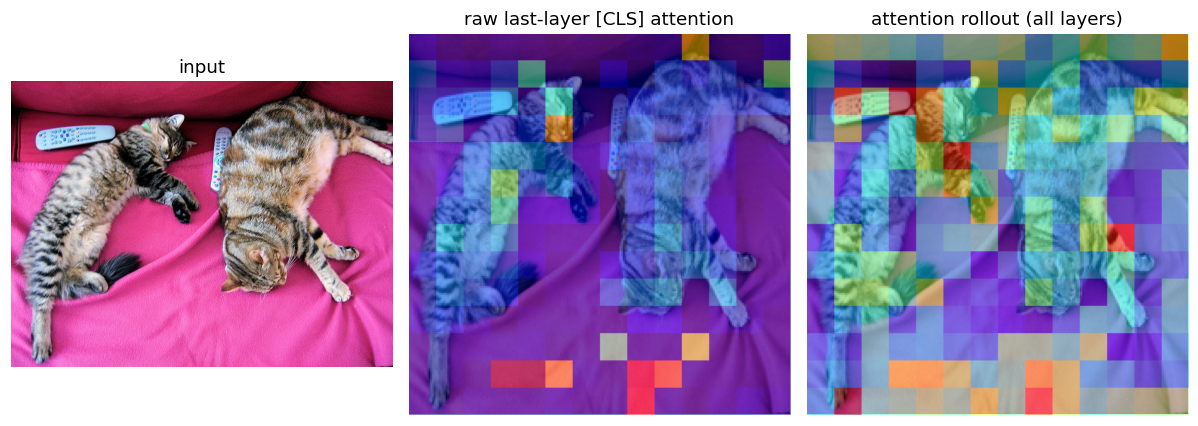

In [41]:
# =============================================================================
# Vision Transformer Attention Visualization
# =============================================================================
#
# Description:
# This script loads an image, runs it through a Vision Transformer (ViT), and
# visualizes which image patches receive the most attention when producing the
# final [CLS] token representation.
#
# The script compares two attention-based visualisation methods:
#   - Raw last-layer [CLS] attention:
#       Shows the attention paid by the [CLS] token to image patches in the
#       final transformer layer.
#
#   - Attention rollout:
#       Combines attention information across all transformer layers to
#       estimate how information propagates from image patches to the [CLS]
#       token.
#
# Residual connections are incorporated into the rollout by mixing each
# attention matrix with the identity matrix before multiplying the matrices
# across layers.
#
# The input image is divided into a 14 x 14 grid of image patches, matching
# the patch-token structure used by the ViT model in this experiment.
#
# The resulting figure contains:
#   1. The original input image.
#   2. A heatmap based on raw last-layer [CLS] attention.
#   3. A heatmap based on attention rollout across all layers.
#
# The script also prints the model's predicted ImageNet class label.
#
# Requirements:
#   - PyTorch
#   - Transformers
#   - NumPy
#   - Matplotlib
#   - Requests
#   - Pillow
#
# Assumptions:
#   - proc is an image processor compatible with the ViT model.
#   - vit is a pretrained Vision Transformer model.
#   - device is already defined.
#   - imgs is available as a fallback image list.
#   - free() is already defined for memory cleanup.
#
# =============================================================================

import requests
from PIL import Image
try:
    cat = Image.open(requests.get("http://images.cocodataset.org/val2017/000000039769.jpg", stream=True).raw).convert("RGB")
except Exception:
    cat = imgs[0]
px1 = proc(images=cat, return_tensors="pt").pixel_values.to(device)
with torch.no_grad(): out = vit(px1, output_attentions=True)
print("ViT prediction:", vit.config.id2label[out.logits.argmax(-1).item()])

def rollout_matrices(attn_list):                       # list of (N,N) head-averaged attention matrices
    N = attn_list[0].shape[-1]; I = torch.eye(N); R = torch.eye(N)
    for a in attn_list:
        a = 0.5 * a + 0.5 * I; a = a / a.sum(-1, keepdim=True); R = a @ R
    return R

A_vit = [a[0].mean(0).float().cpu() for a in out.attentions]
R = rollout_matrices(A_vit)
sal = R[0, 1:].reshape(14, 14).numpy(); raw = A_vit[-1][0, 1:].reshape(14, 14).numpy()
fig, ax = plt.subplots(1, 3, figsize=(11, 3.8))
ax[0].imshow(cat); ax[0].set_title("input")
for a_, m_, t_ in [(ax[1], raw, "raw last-layer [CLS] attention"), (ax[2], sal, "attention rollout (all layers)")]:
    a_.imshow(cat.resize((224, 224))); a_.imshow(np.kron(m_ / m_.max(), np.ones((16, 16))), cmap="jet", alpha=0.5, extent=(0, 224, 224, 0)); a_.set_title(t_)
for a_ in ax: a_.axis("off")
plt.tight_layout(); plt.show()
del vit; free()

### 7.2 Rollout vs. attention flow on GPT-2
Graph: nodes = (layer, token), edge capacity = head-averaged attention (+ residual, row-normalised). **Rollout** sums products over all paths, **flow** computes the maximum flow from an input token to the last token's final-layer node with `networkx`. Both are compared with the raw last-layer attention of the last token.

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

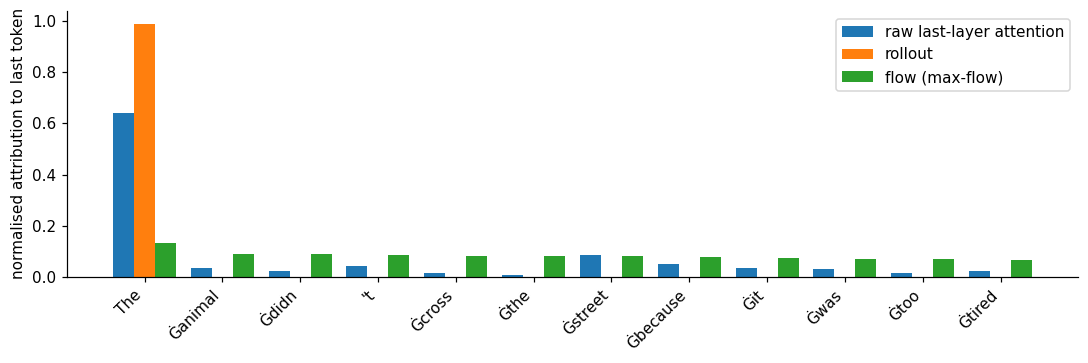

     token     raw  rollout    flow
       The   0.640    0.991   0.132
   Ġanimal   0.035    0.001   0.090
     Ġdidn   0.022    0.001   0.088
        't   0.041    0.001   0.086
    Ġcross   0.014    0.001   0.083
      Ġthe   0.007    0.001   0.083
   Ġstreet   0.087    0.001   0.082
  Ġbecause   0.050    0.001   0.076
       Ġit   0.035    0.001   0.073
      Ġwas   0.032    0.001   0.071
      Ġtoo   0.014    0.001   0.069
    Ġtired   0.023    0.001   0.067


In [42]:
# =============================================================================
# Attention Attribution: Raw Attention, Rollout, and Max-Flow
# =============================================================================
#
# Description:
# This script analyzes how information from different input tokens contributes
# to the representation of the final token in a GPT-2 language model.
#
# Three attribution methods are compared:
#   - Raw last-layer attention:
#       Direct attention weights from the final layer for the last token.
#
#   - Attention rollout:
#       Combines attention matrices across all transformer layers to estimate
#       how information propagates from the input tokens to the final token.
#
#   - Maximum-flow attribution:
#       Builds a layered directed graph from the residual-adjusted attention
#       matrices and uses maximum flow to measure the strongest information
#       pathways from each input token to the final token.
#
# The experiment uses the sentence:
#   "The animal didn't cross the street because it was too tired"
#
# GPT-2 attention weights are extracted for all transformer layers and averaged
# across attention heads. Residual connections are incorporated by mixing each
# attention matrix with the identity matrix before constructing the flow graph.
#
# The resulting bar chart compares the normalised attribution assigned to each
# token by the three methods.
#
# The script also prints a table containing the attribution values for each
# token and releases the GPT-2 model from memory after the experiment.
#
# Requirements:
#   - PyTorch
#   - Transformers
#   - NumPy
#   - Matplotlib
#   - NetworkX
#
# Assumptions:
#   - tok_g is a GPT-2-compatible tokenizer.
#   - device is already defined.
#   - rollout_matrices() is already defined.
#   - free() is already defined for memory cleanup.
#
# =============================================================================

import networkx as nx
gpt_e = AutoModelForCausalLM.from_pretrained("gpt2", torch_dtype=torch.float32, attn_implementation="eager").to(device).eval()
sentence = "The animal didn't cross the street because it was too tired"
enc = tok_g(sentence, return_tensors="pt").to(device); tks = tok_g.convert_ids_to_tokens(enc.input_ids[0]); n = len(tks)
with torch.no_grad(): o = gpt_e(**enc, output_attentions=True)
A_l = [a[0].mean(0).float().cpu() for a in o.attentions]                     # 12 x (n, n): A[i, j] = query i attends key j
Lyr = len(A_l); I = torch.eye(n)
A_res = [(0.5 * a + 0.5 * I) / (0.5 * a + 0.5 * I).sum(-1, keepdim=True) for a in A_l]

Rg = rollout_matrices(A_l)                                                     # information from input j to output i
G = nx.DiGraph()
for l, a in enumerate(A_res):
    for i in range(n):
        for j in range(n):
            if a[i, j] > 1e-4: G.add_edge((l, j), (l + 1, i), capacity=float(a[i, j]))
sink = (Lyr, n - 1)
flow = np.array([nx.maximum_flow_value(G, (0, j), sink) if (0, j) in G else 0.0 for j in range(n)])
roll = Rg[n - 1].numpy(); rawl = A_l[-1][n - 1].numpy()
nz = lambda v: v / v.sum()
fig, ax = plt.subplots(figsize=(10, 3.4)); xs = np.arange(n); wd = 0.27
ax.bar(xs - wd, nz(rawl), wd, label="raw last-layer attention"); ax.bar(xs, nz(roll), wd, label="rollout"); ax.bar(xs + wd, nz(flow), wd, label="flow (max-flow)")
ax.set_xticks(xs); ax.set_xticklabels(tks, rotation=45, ha="right"); ax.set_ylabel("normalised attribution to last token"); ax.legend(); plt.tight_layout(); plt.show()
print(f"{'token':>10} {'raw':>7} {'rollout':>8} {'flow':>7}")
for t_, a_, b_, c_ in zip(tks, nz(rawl), nz(roll), nz(flow)): print(f"{t_:>10} {a_:>7.3f} {b_:>8.3f} {c_:>7.3f}")
del gpt_e; free()